# 07: PCA com sklearn + LDA

Comparação prática entre PCA (não supervisionado) e LDA (supervisionado) usando o dataset Iris.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

## 1. PCA NumPy - Passo a Passo

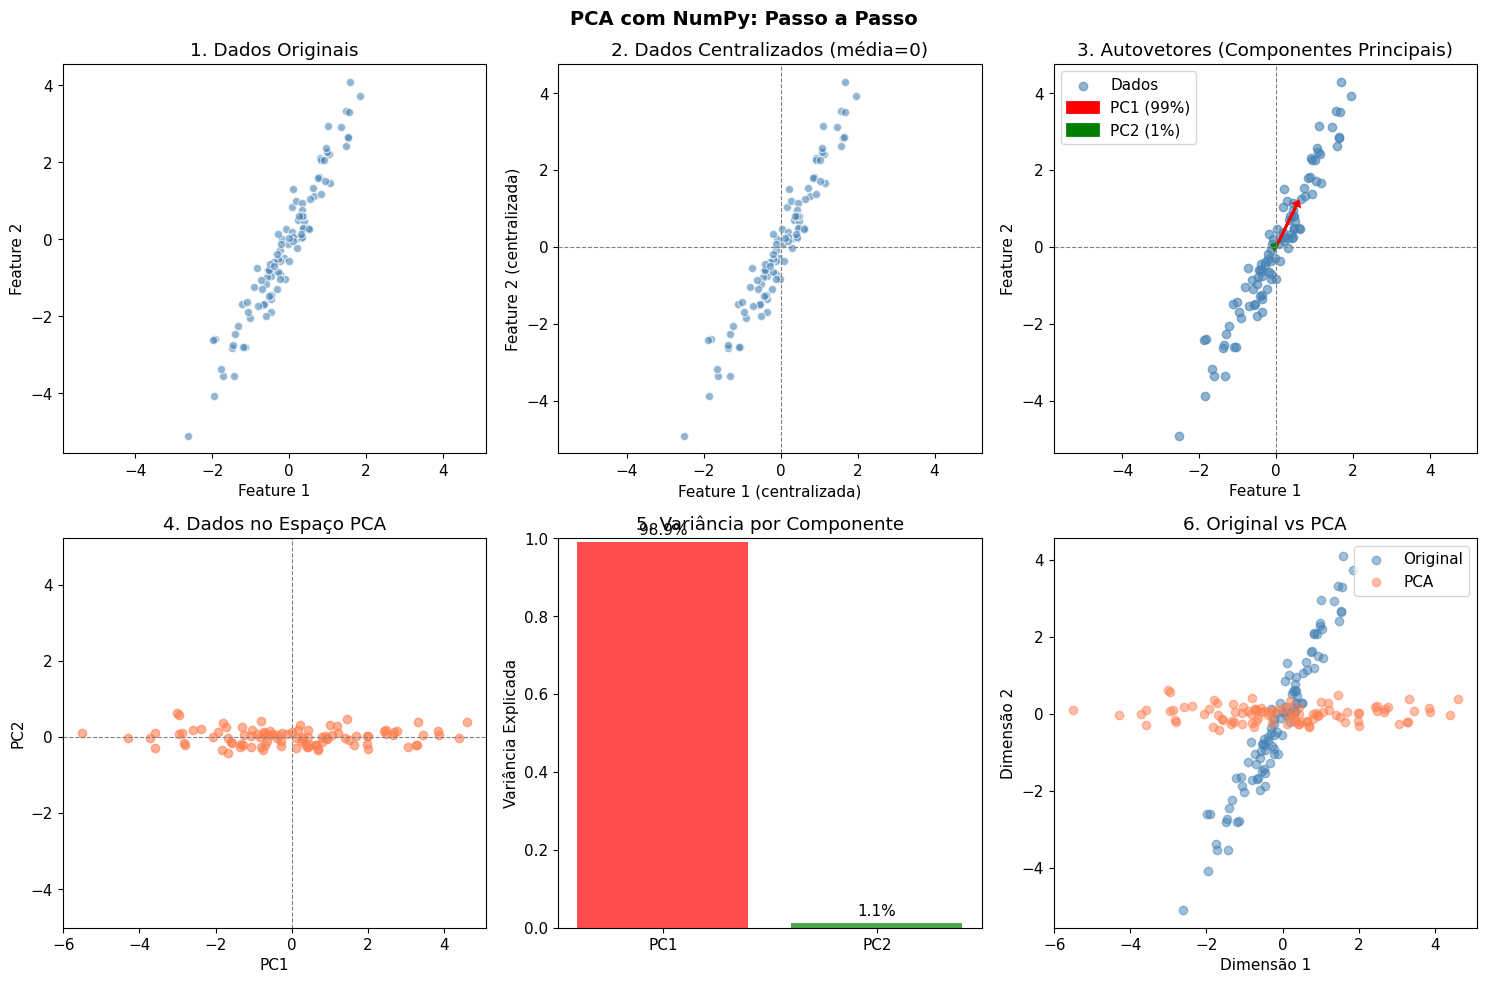

Gráfico salvo: ../graficos/pca_numpy_passo-a-passo.png


In [2]:
np.random.seed(42)
x = np.random.randn(100)
y = 2 * x + np.random.randn(100) * 0.5
X = np.column_stack((x, y))

# Centralizar
media = X.mean(axis=0)
X_centered = X - media

# Covariância
cov_matrix = np.cov(X_centered.T)

# Autovetores
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Variância explicada
total_variance = eigenvalues.sum()
variance_ratio = eigenvalues / total_variance

# Transformar
X_pca = X_centered @ eigenvectors

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Dados originais
axes[0, 0].scatter(X[:, 0], X[:, 1], alpha=0.6, c='steelblue', edgecolors='white')
axes[0, 0].set_xlabel('Feature 1')
axes[0, 0].set_ylabel('Feature 2')
axes[0, 0].set_title('1. Dados Originais')
axes[0, 0].axis('equal')

# 2. Dados centralizados
axes[0, 1].scatter(X_centered[:, 0], X_centered[:, 1], alpha=0.6, c='steelblue', edgecolors='white')
axes[0, 1].axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
axes[0, 1].axvline(x=0, color='gray', linestyle='--', linewidth=0.8)
axes[0, 1].set_xlabel('Feature 1 (centralizada)')
axes[0, 1].set_ylabel('Feature 2 (centralizada)')
axes[0, 1].set_title('2. Dados Centralizados (média=0)')
axes[0, 1].axis('equal')

# 3. Autovetores
axes[0, 2].scatter(X_centered[:, 0], X_centered[:, 1], alpha=0.6, c='steelblue', label='Dados')
for i in range(len(eigenvalues)):
    arrow = eigenvectors[:, i] * eigenvalues[i] * 0.3
    color = 'red' if i == 0 else 'green'
    label = f'PC{i+1} ({variance_ratio[i]:.0%})'
    axes[0, 2].arrow(0, 0, arrow[0], arrow[1], head_width=0.15, head_length=0.1,
                      fc=color, ec=color, linewidth=2, label=label)
axes[0, 2].axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
axes[0, 2].axvline(x=0, color='gray', linestyle='--', linewidth=0.8)
axes[0, 2].set_xlabel('Feature 1')
axes[0, 2].set_ylabel('Feature 2')
axes[0, 2].set_title('3. Autovetores (Componentes Principais)')
axes[0, 2].legend()
axes[0, 2].axis('equal')

# 4. Dados no espaço PCA
axes[1, 0].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, c='coral')
axes[1, 0].axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
axes[1, 0].axvline(x=0, color='gray', linestyle='--', linewidth=0.8)
axes[1, 0].set_xlabel('PC1')
axes[1, 0].set_ylabel('PC2')
axes[1, 0].set_title('4. Dados no Espaço PCA')
axes[1, 0].axis('equal')

# 5. Variância explicada
axes[1, 1].bar(['PC1', 'PC2'], variance_ratio, alpha=0.7, color=['red', 'green'])
axes[1, 1].set_ylabel('Variância Explicada')
axes[1, 1].set_title('5. Variância por Componente')
axes[1, 1].set_ylim(0, 1)
for i, v in enumerate(variance_ratio):
    axes[1, 1].text(i, v + 0.02, f'{v:.1%}', ha='center')

# 6. Comparação
axes[1, 2].scatter(X[:, 0], X[:, 1], alpha=0.5, c='steelblue', label='Original')
axes[1, 2].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, c='coral', label='PCA')
axes[1, 2].set_xlabel('Dimensão 1')
axes[1, 2].set_ylabel('Dimensão 2')
axes[1, 2].set_title('6. Original vs PCA')
axes[1, 2].legend()

plt.suptitle('PCA com NumPy: Passo a Passo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../graficos/pca_numpy_passo-a-passo.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo: ../graficos/pca_numpy_passo-a-passo.png')

## 2. Setup - Iris Dataset

In [3]:
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_iris)

colors = ['#e74c3c', '#2ecc71', '#3498db']
species = iris.target_names

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_iris, test_size=0.3, random_state=42)

print(f'Treino: {X_train.shape[0]} amostras')
print(f'Teste: {X_test.shape[0]} amostras')

Treino: 105 amostras
Teste: 45 amostras


## 3. PCA Sklearn - Variância Explicada

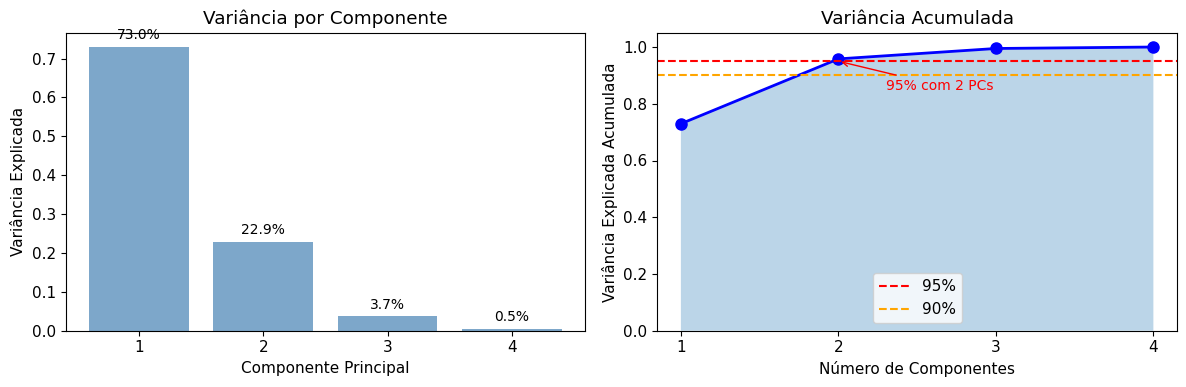

Gráfico salvo: ../graficos/pca_sklearn_variancia_explicada.png


In [4]:
pca_full = PCA()
pca_full.fit(X_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barras
axes[0].bar(range(1, 5), pca_full.explained_variance_ratio_, alpha=0.7, color='steelblue')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Variância Explicada')
axes[0].set_title('Variância por Componente')
axes[0].set_xticks(range(1, 5))
for i, v in enumerate(pca_full.explained_variance_ratio_):
    axes[0].text(i+1, v + 0.02, f'{v:.1%}', ha='center', fontsize=10)

# Acumulada
axes[1].plot(range(1, 5), cumulative_variance, 'bo-', linewidth=2, markersize=8)
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95%')
axes[1].axhline(y=0.90, color='orange', linestyle='--', label='90%')
axes[1].fill_between(range(1, 5), cumulative_variance, alpha=0.3)
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Variância Explicada Acumulada')
axes[1].set_title('Variância Acumulada')
axes[1].set_xticks(range(1, 5))
axes[1].set_ylim(0, 1.05)
axes[1].legend()

n_95 = np.argmax(cumulative_variance >= 0.95) + 1
axes[1].annotate(f'95% com {n_95} PCs', xy=(n_95, 0.95), xytext=(n_95+0.3, 0.85),
                arrowprops=dict(arrowstyle='->', color='red'), fontsize=10, color='red')

plt.tight_layout()
plt.savefig('../graficos/pca_sklearn_variancia_explicada.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo: ../graficos/pca_sklearn_variancia_explicada.png')

## 4. Gráfico de Cotovelo

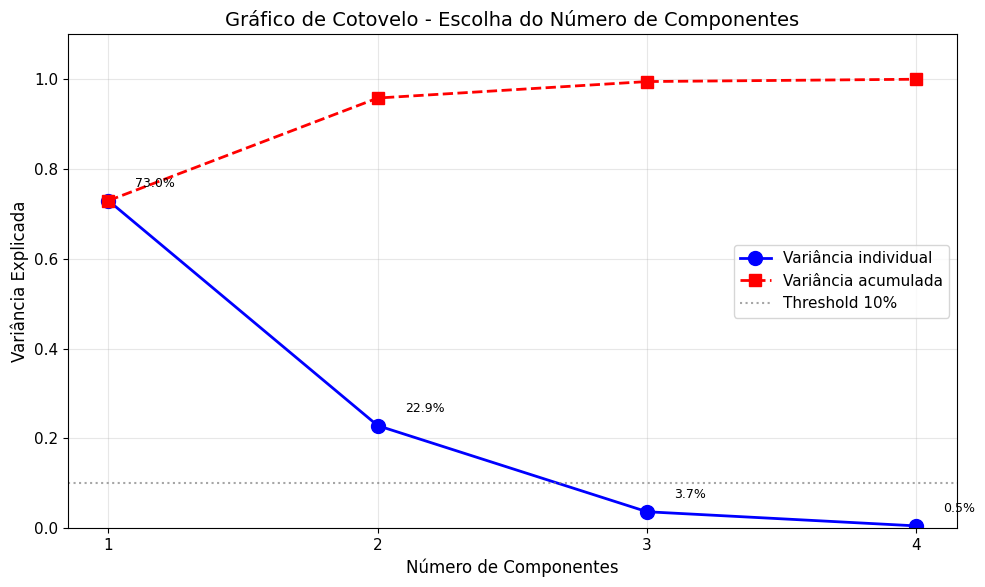

Gráfico salvo: ../graficos/pca_sklearn_cotovelo.png


In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(range(1, 5), pca_full.explained_variance_ratio_, 'bo-', linewidth=2, markersize=10, label='Variância individual')
ax.plot(range(1, 5), cumulative_variance, 'rs--', linewidth=2, markersize=8, label='Variância acumulada')
ax.axhline(y=0.10, color='gray', linestyle=':', alpha=0.7, label='Threshold 10%')
ax.set_xlabel('Número de Componentes', fontsize=12)
ax.set_ylabel('Variância Explicada', fontsize=12)
ax.set_title('Gráfico de Cotovelo - Escolha do Número de Componentes', fontsize=14)
ax.set_xticks(range(1, 5))
ax.set_ylim(0, 1.1)
ax.legend(loc='center right')
ax.grid(True, alpha=0.3)

for i, (var, cum) in enumerate(zip(pca_full.explained_variance_ratio_, cumulative_variance)):
    ax.annotate(f'{var:.1%}', xy=(i+1, var), xytext=(i+1.1, var+0.03), fontsize=9)

plt.tight_layout()
plt.savefig('../graficos/pca_sklearn_cotovelo.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo: ../graficos/pca_sklearn_cotovelo.png')

## 5. PCA 2D Scatter

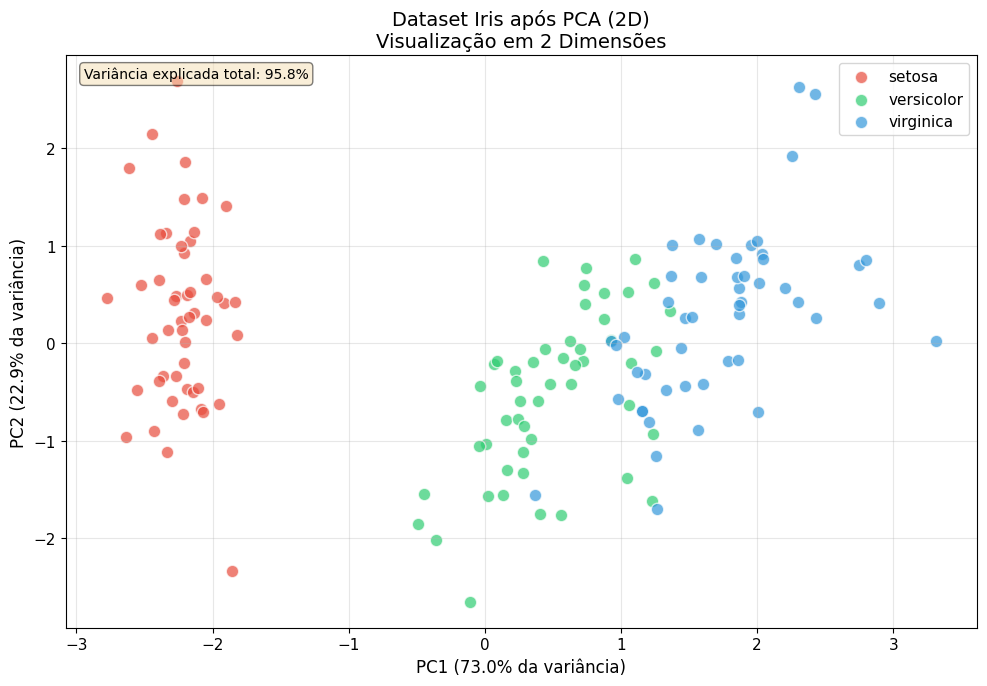

Gráfico salvo: ../graficos/pca_2d_scatter.png


In [6]:
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 7))

for i, (color, sp) in enumerate(zip(colors, species)):
    mask = y_iris == i
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=color, label=sp, alpha=0.7, edgecolors='white', s=80)

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} da variância)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} da variância)', fontsize=12)
ax.set_title('Dataset Iris após PCA (2D)\nVisualização em 2 Dimensões', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

info_text = f'Variância explicada total: {pca_2d.explained_variance_ratio_.sum():.1%}'
ax.text(0.02, 0.98, info_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('../graficos/pca_2d_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo: ../graficos/pca_2d_scatter.png')

## 6. LDA 2D Scatter

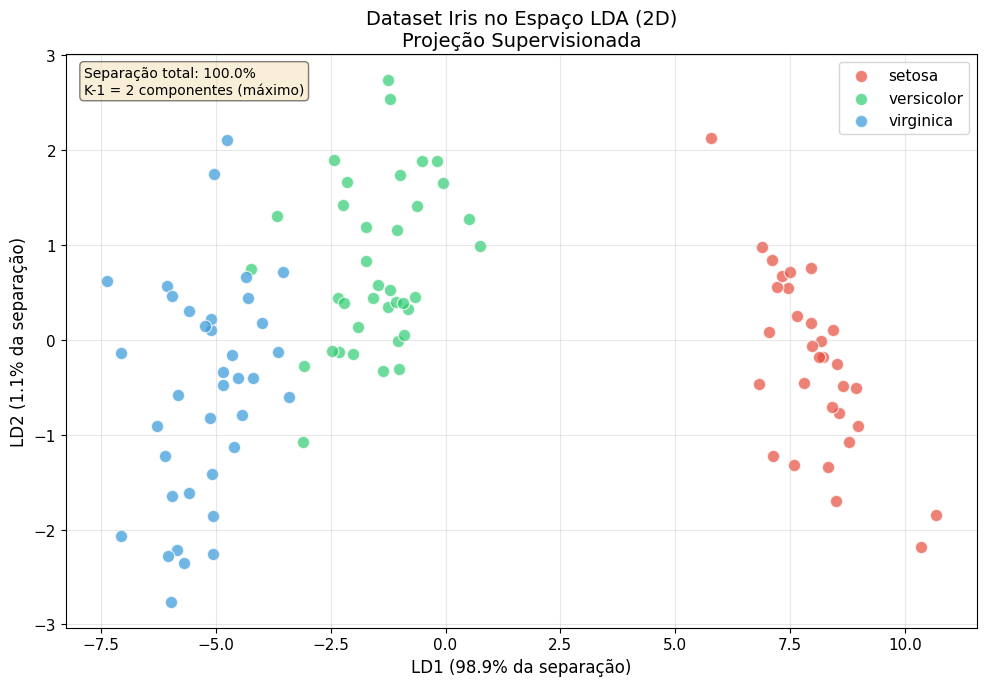

Gráfico salvo: ../graficos/lda_2d_scatter.png


In [7]:
lda = LinearDiscriminantAnalysis(n_components=2)
X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)

fig, ax = plt.subplots(figsize=(10, 7))

for i, (color, sp) in enumerate(zip(colors, species)):
    mask = y_train == i
    ax.scatter(X_train_lda[mask, 0], X_train_lda[mask, 1],
               c=color, label=sp, alpha=0.7, edgecolors='white', s=80)

ax.set_xlabel(f'LD1 ({lda.explained_variance_ratio_[0]:.1%} da separação)', fontsize=12)
ax.set_ylabel(f'LD2 ({lda.explained_variance_ratio_[1]:.1%} da separação)', fontsize=12)
ax.set_title('Dataset Iris no Espaço LDA (2D)\nProjeção Supervisionada', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

info_text = f'Separação total: {sum(lda.explained_variance_ratio_):.1%}\nK-1 = {min(2, len(species)-1)} componentes (máximo)'
ax.text(0.02, 0.98, info_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('../graficos/lda_2d_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo: ../graficos/lda_2d_scatter.png')

## 7. PCA vs LDA - Comparação Direta

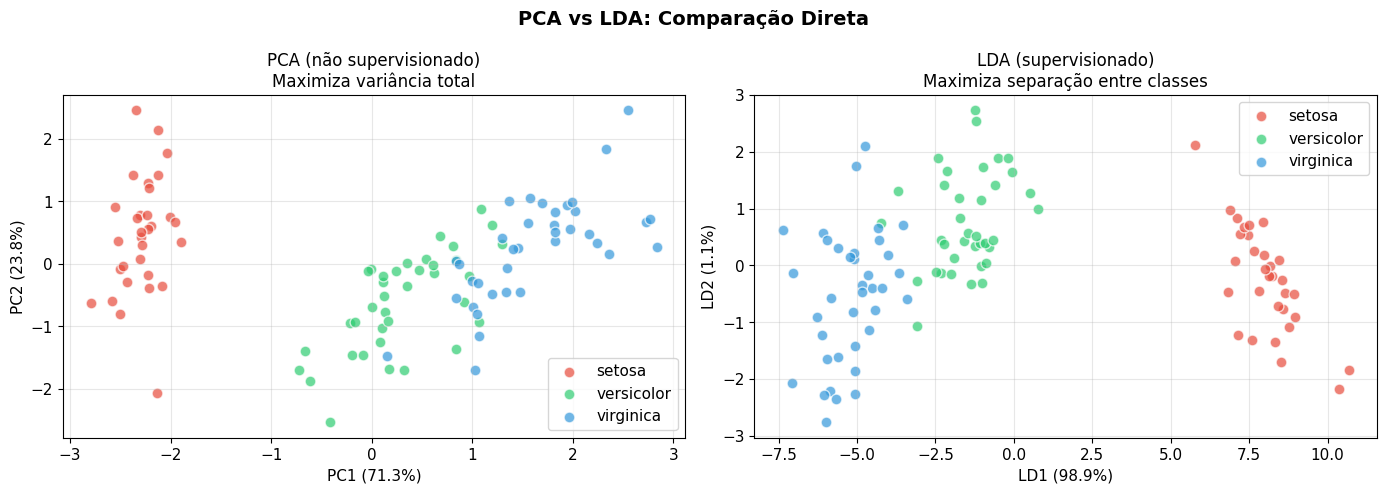

Gráfico salvo: ../graficos/pca_vs_lda_comparacao.png


In [8]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PCA
for i, (color, sp) in enumerate(zip(colors, species)):
    mask = y_train == i
    axes[0].scatter(X_train_pca[mask, 0], X_train_pca[mask, 1],
                    c=color, label=sp, alpha=0.7, edgecolors='white', s=60)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[0].set_title('PCA (não supervisionado)\nMaximiza variância total', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# LDA
for i, (color, sp) in enumerate(zip(colors, species)):
    mask = y_train == i
    axes[1].scatter(X_train_lda[mask, 0], X_train_lda[mask, 1],
                    c=color, label=sp, alpha=0.7, edgecolors='white', s=60)
axes[1].set_xlabel(f'LD1 ({lda.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'LD2 ({lda.explained_variance_ratio_[1]:.1%})')
axes[1].set_title('LDA (supervisionado)\nMaximiza separação entre classes', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('PCA vs LDA: Comparação Direta', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../graficos/pca_vs_lda_comparacao.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo: ../graficos/pca_vs_lda_comparacao.png')

## 8. Iris PCA + LDA - Treino e Teste

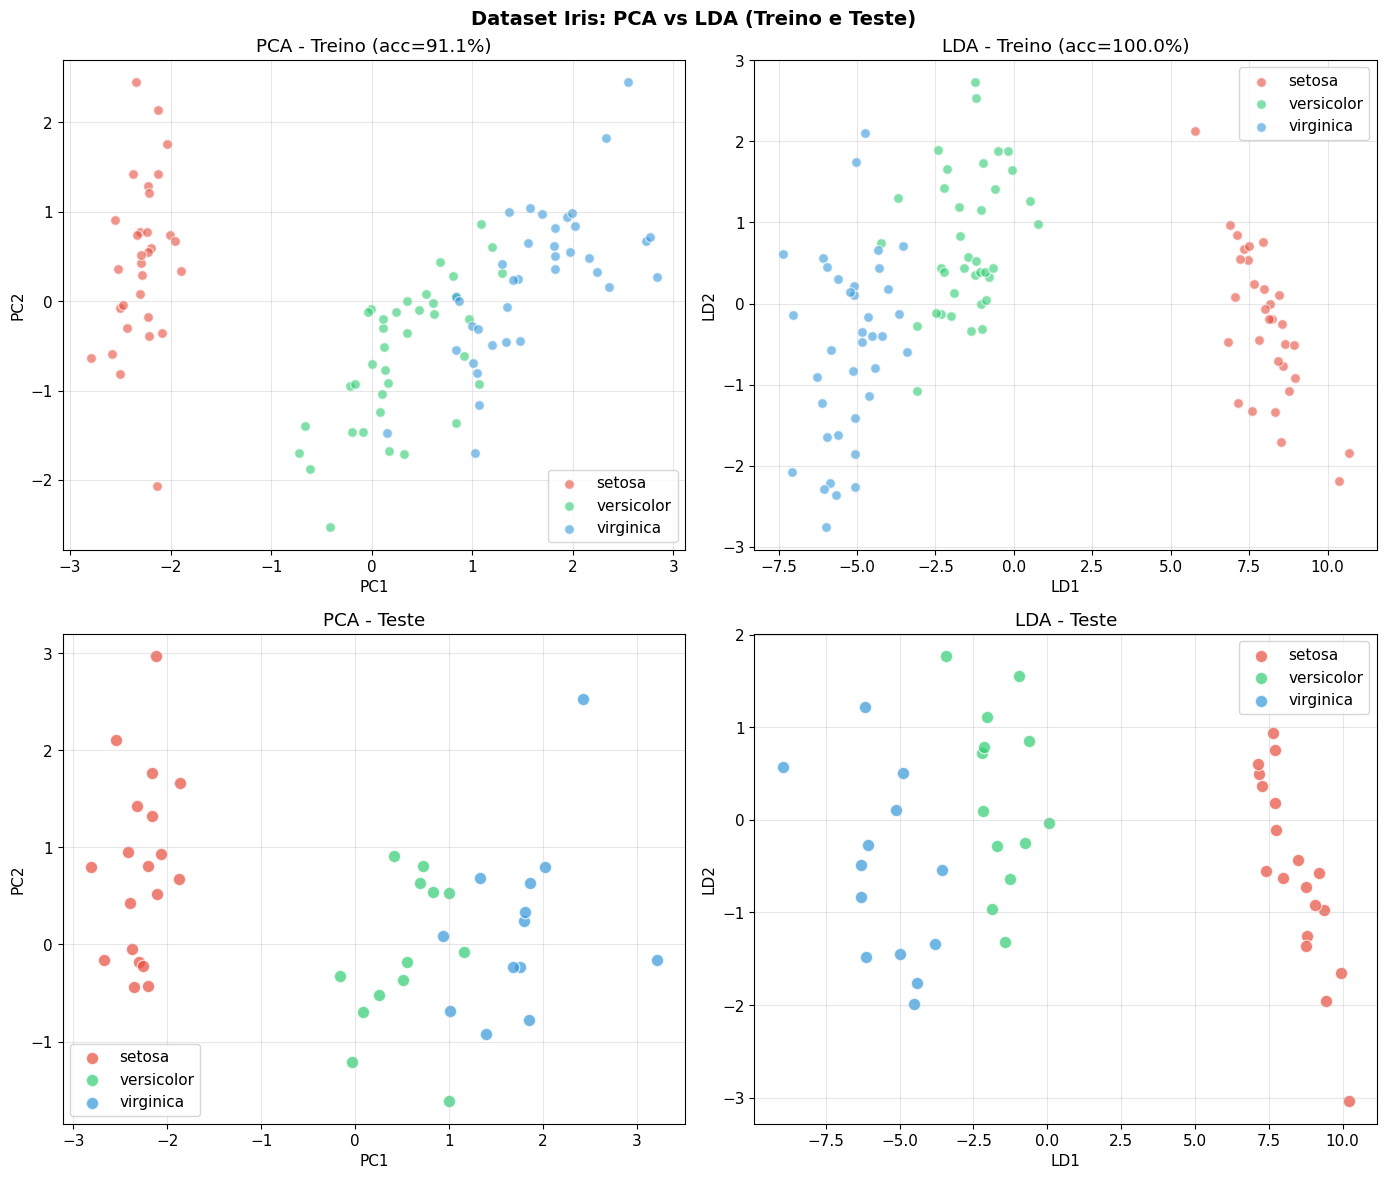

Gráfico salvo: ../graficos/iris_pca_lda_lado_a_lado.png


In [9]:
clf_pca = LogisticRegression(random_state=42)
clf_pca.fit(X_train_pca, y_train)
acc_pca = accuracy_score(y_test, clf_pca.predict(pca.transform(X_test)))

clf_lda = LogisticRegression(random_state=42)
clf_lda.fit(X_train_lda, y_train)
acc_lda = accuracy_score(y_test, clf_lda.predict(X_test_lda))

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# PCA - Treino
for i, (color, sp) in enumerate(zip(colors, species)):
    mask = y_train == i
    axes[0, 0].scatter(X_train_pca[mask, 0], X_train_pca[mask, 1],
                       c=color, label=sp, alpha=0.6, edgecolors='white', s=50)
axes[0, 0].set_xlabel('PC1')
axes[0, 0].set_ylabel('PC2')
axes[0, 0].set_title(f'PCA - Treino (acc={acc_pca:.1%})')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# LDA - Treino
for i, (color, sp) in enumerate(zip(colors, species)):
    mask = y_train == i
    axes[0, 1].scatter(X_train_lda[mask, 0], X_train_lda[mask, 1],
                       c=color, label=sp, alpha=0.6, edgecolors='white', s=50)
axes[0, 1].set_xlabel('LD1')
axes[0, 1].set_ylabel('LD2')
axes[0, 1].set_title(f'LDA - Treino (acc={acc_lda:.1%})')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# PCA - Teste
X_test_pca = pca.transform(X_test)
for i, (color, sp) in enumerate(zip(colors, species)):
    mask = y_test == i
    axes[1, 0].scatter(X_test_pca[mask, 0], X_test_pca[mask, 1],
                       c=color, label=sp, alpha=0.7, edgecolors='white', s=80)
axes[1, 0].set_xlabel('PC1')
axes[1, 0].set_ylabel('PC2')
axes[1, 0].set_title('PCA - Teste')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# LDA - Teste
for i, (color, sp) in enumerate(zip(colors, species)):
    mask = y_test == i
    axes[1, 1].scatter(X_test_lda[mask, 0], X_test_lda[mask, 1],
                       c=color, label=sp, alpha=0.7, edgecolors='white', s=80)
axes[1, 1].set_xlabel('LD1')
axes[1, 1].set_ylabel('LD2')
axes[1, 1].set_title('LDA - Teste')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Dataset Iris: PCA vs LDA (Treino e Teste)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../graficos/iris_pca_lda_lado_a_lado.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo: ../graficos/iris_pca_lda_lado_a_lado.png')